In [1]:
!pip install datasets
!pip install wordcloud
from wordcloud import WordCloud
from datasets import load_dataset
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_predict
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import learning_curve
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import gensim.downloader as api
import nltk
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import ssl
import pandas as pd
import os
import numpy as np 


 
dataset = load_dataset ("ailsntua/QEvasion")
df_train = pd.DataFrame(dataset['train'])
df_test = pd.DataFrame(dataset['test'])

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/3.90M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/259k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3448 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/308 [00:00<?, ? examples/s]

In [2]:
president_column: pd.Series = df_train['president'].describe()
print(president_column)

count                3448
unique                  4
top       Donald J. Trump
freq                 1325
Name: president, dtype: object


In [3]:
president_names = df_train['president'].unique()
print(president_names)

['Joseph R. Biden' 'Donald J. Trump' 'Barack Obama' 'George W. Bush']


In [4]:
president_counts = df_train['president'].value_counts()
print(president_counts)

president
Donald J. Trump    1325
Barack Obama       1010
George W. Bush      714
Joseph R. Biden     399
Name: count, dtype: int64


Αρχικά, προτού κάνουμε οποιαδήποτε ανάλυση, πραγματοποιούμε έλεγχο για ελλιπείς τιμές και διπλότυπες εγγραφές. Έτσι, διασφαλίζουμε ότι το μοντέλο δεν θα εκπαιδευτεί σε πλεονάζουσα πληροφορία.

In [5]:
print (f"Αρχικό μέγεθος dataset: {df_train.shape}")
print ("Κενές τιμές ανά στήλη:")
print (df_train.isnull().sum())

df_train = df_train.dropna(subset=['question', 'interview_answer', 'clarity_label']) #Αφαιρώ γραμμές με κενό στην ερώτηση, στην απάντηση ή στο label 

duplicates_count = df_train.duplicated(subset=['question', 'interview_answer']).sum()
print(f"\nΒρέθηκαν {duplicates_count} διπλότυπα κείμενα.")

if duplicates_count > 0:
    df_train = df_train.drop_duplicates(subset=['question', 'interview_answer'])
    print ("Τα διπλότυπα αφαιρέθηκαν επιτυχώς.")

print(f"\n Τελικό μέγεθος dataset: {df_train.shape}")

Αρχικό μέγεθος dataset: (3448, 20)
Κενές τιμές ανά στήλη:
title                       0
date                        0
president                   0
url                         0
question_order              0
interview_question          0
interview_answer            0
gpt3.5_summary              0
gpt3.5_prediction           0
question                    0
annotator_id                0
annotator1               3448
annotator2               3448
annotator3               3448
inaudible                   0
multiple_questions          0
affirmative_questions       0
index                       0
clarity_label               0
evasion_label               0
dtype: int64

Βρέθηκαν 58 διπλότυπα κείμενα.
Τα διπλότυπα αφαιρέθηκαν επιτυχώς.

 Τελικό μέγεθος dataset: (3390, 20)


In [6]:
df_train ['word_count'] = df_train ['interview_answer'].apply(lambda x: len(str(x).split()))

print ("Στατιστικά μήκους κειμένου (σε λέξεις):")
stats = df_train ['word_count'].describe()
print (stats)

Στατιστικά μήκους κειμένου (σε λέξεις):
count    3390.000000
mean      294.017994
std       300.958722
min         1.000000
25%        58.250000
50%       208.000000
75%       440.000000
max      2117.000000
Name: word_count, dtype: float64


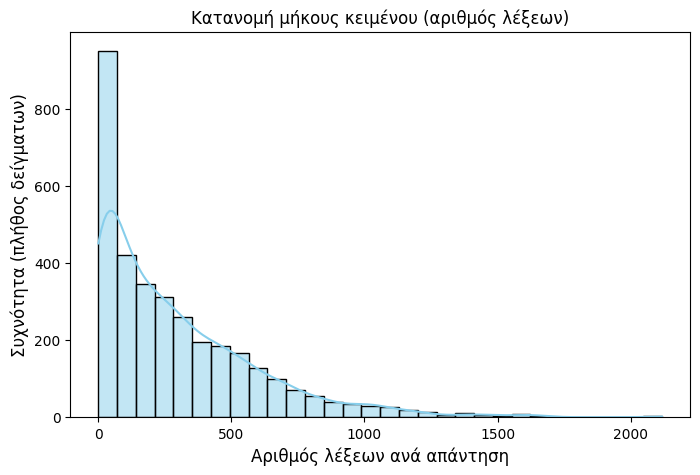

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5)) #Ορίζω μέγεθος γραφήματος
sns.histplot(df_train['word_count'], bins=30, kde=True, color='skyblue') #Φτίαχνω ιστόγραμμα για το μήκος κειμένου

plt.title('Κατανομή μήκους κειμένου (αριθμός λέξεων)', fontsize=12)
plt.xlabel('Αριθμός λέξεων ανά απάντηση', fontsize=12)
plt.ylabel('Συχνότητα (πλήθος δείγματων)', fontsize=12)
plt.savefig('word_count.png', bbox_inches='tight', dpi=300)

plt.show()

Το ιστόγραμμα δείχνει ότι οι περισσότερες απαντήσεις είναι σύντομες, καθώς η κατανομή είναι συγκεντρωμένη στα αριστερά, γεγονός που υποδηλώνει την προτίμηση των πολιτικών για περιεκτικές τοποθετήσεις. Επιπλέον, υπάρχουν ελάχιστα "outliers" που περιλαμβάνουν, συγκριτικά, μεγαλύτερο αριθμό λέξεων. 

In [8]:
label_counts = df_train['clarity_label'].value_counts()
print("Πλήθος δειγμάτων ανά κλάση:\n", label_counts)
print("\n" + "-"*30 + "\n")

label_percentages = df_train['clarity_label'].value_counts(normalize=True)*100
print("Ποσοστά ανά κλάση (%):\n", label_percentages)

Πλήθος δειγμάτων ανά κλάση:
 clarity_label
Ambivalent         2004
Clear Reply        1037
Clear Non-Reply     349
Name: count, dtype: int64

------------------------------

Ποσοστά ανά κλάση (%):
 clarity_label
Ambivalent         59.115044
Clear Reply        30.589971
Clear Non-Reply    10.294985
Name: proportion, dtype: float64


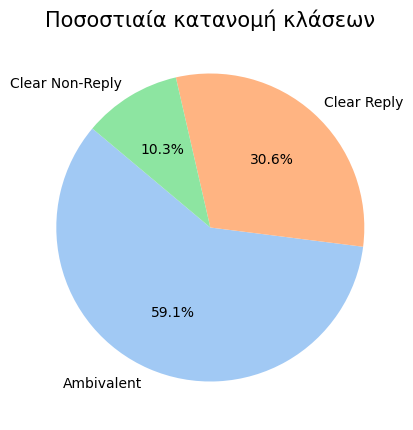

In [9]:
plt.figure(figsize=(5,5))
plt.pie(label_counts, labels = label_counts.index, autopct='%1.1f%%', startangle=140, colors = sns.color_palette('pastel'))

plt.title('Ποσοστιαία κατανομή κλάσεων', fontsize=15)
plt.savefig('class_percentage.png', bbox_inches='tight', dpi=300)
plt.show()

Παρατηρείται σημαντική ανισορροπία μεταξύ των κλάσεων, γεγονός το οποίο καθιστά απαραίτητη τη χρήση της εντολής stratify κατά τον διαχωρισμό των δεδομένων, ώστε να διατηρηθεί η αναλογία του training set αυτούσια στο validation set.

Σε αυτό το στάδιο κρίνεται απαραίτητη η προεπεξεργασία του κειμένου, ώστε να εξασφαλιστεί η αποτελεσματικότερη επεξεργασία του από το μοντέλο. Αρχικά, πραγματοποιούμε συνένωση της ερώτηση και της απάντησης σε ενιαίο κείμενο εξόδου, χρησιμοποιώντας το διαχωριστικό token SEPTOKEN για σαφή διαχωρισμό των δύο μερών. Έπειτα, εφαρμόζουμε διαδικασίες:
1) Lοwercasing
2) Punctuation, URL & Number Removal
3) Whitespace Normalization 
4) Stopword Removal 

In [10]:
import re
import nltk
from nltk.corpus import stopwords

negations = {'no', 'not', 'nor', 'neither', 'never', 'none', 'but'}
stop_words = set(stopwords.words('english')) 
stop_words = stop_words - negations

def clean_text(text):
    text = text.lower() #Μετατροπή σε πεζά γράμματα
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE) #Αφαίρεση links
    text = re.sub(r'[^\w\s]', '', text) #Αφαίρεση σημείων στίξης
    text = re.sub(r'\d+', '', text) #Αφαίρεση αριθμών
    all_words = text.split()
    clean_words = [w for w in all_words if w not in stop_words and len(w) > 2] #Αφαίρεση stopwords και μικρών λέξεων
    return " ".join(clean_words)

In [11]:
df_train['clean_question'] = df_train['question'].apply(clean_text)
df_train['clean_answer'] = df_train['interview_answer'].apply(clean_text)
df_train['clean_text'] = df_train['clean_question'] + " SEPTOKEN " + df_train['clean_answer']

df_test['clean_question'] = df_test['question'].apply(clean_text)
df_test['clean_answer'] = df_test['interview_answer'].apply(clean_text)
df_test['clean_text'] = df_test['clean_question'] + " SEPTOKEN " + df_test['clean_answer']


df_train = df_train[df_train['clean_text'].str.len() > 5] #Αφαίρεση μικρών προτάσεων

pd.set_option('display.max_colwidth', None)
print (df_train[['question', 'interview_answer', 'clean_text']].head(2))

                                                                                                                 question  \
0  How would you respond to the accusation that the United States is containing China while pushing for diplomatic talks?   
1      Do you think President Xi is being sincere about getting the relationship back on track as he bans Apple in China?   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                

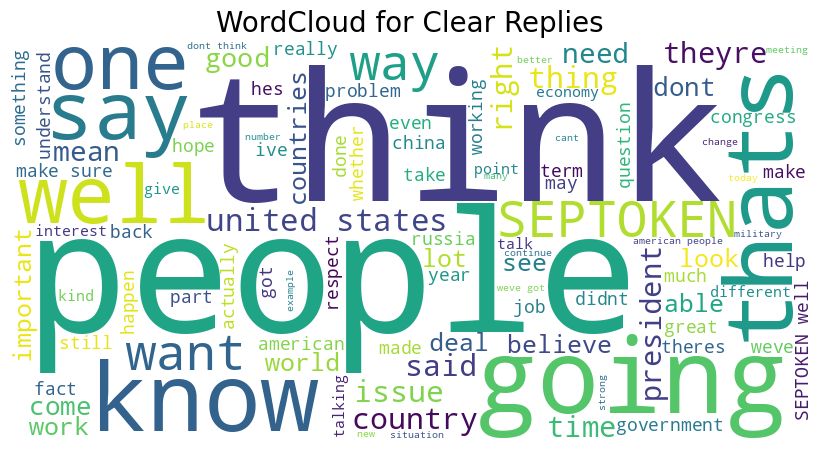

In [12]:
clear_data = df_train[df_train['clarity_label'] == 'Clear Reply']['clean_text']
clear_text_combined = " ".join(clear_data)

wordcloud = WordCloud(
    width = 800, 
    height = 400, 
    background_color ='white', 
    min_font_size = 10,
    max_words = 100,
    colormap = 'viridis' 
).generate(clear_text_combined)


plt.figure(figsize = (8, 5), facecolor = None) 
plt.imshow(wordcloud, interpolation='bilinear') 
plt.axis("off") 
plt.tight_layout(pad = 0) 
plt.title("WordCloud for Clear Replies", fontsize=20)
plt.savefig('wordcloud_clear.png', bbox_inches='tight', dpi=300)
plt.show()

Το WordCloud των ξεκάθαρων απαντήσεων αναδεικνύει πιο άμεσο λεξιλόγιο ενώ, όπως φαίνεται παρακάτω, το Wordcloud των ασαφών απαντήσεων περιέχει περισσότερους όρους επιφύλαξης και υποθετικό λόγο.

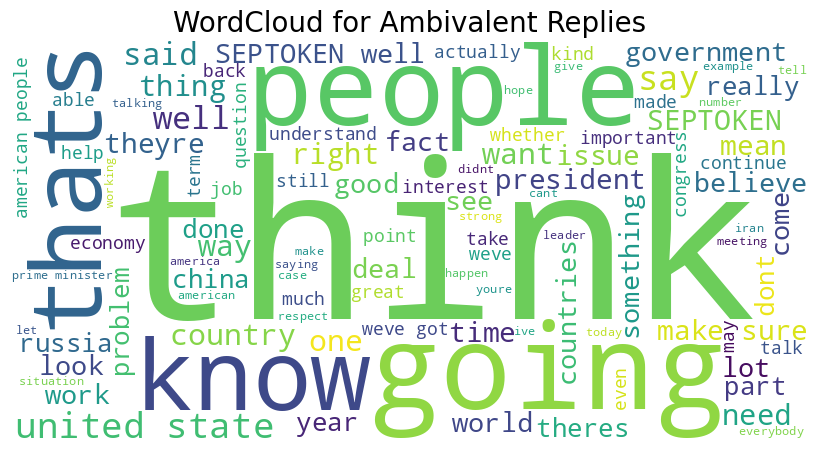

In [13]:
ambivalent_data = df_train[df_train['clarity_label'] == 'Ambivalent']['clean_text']
ambivalent_text_combined = " ".join(ambivalent_data)

wordcloud = WordCloud(
    width = 800, 
    height = 400, 
    background_color ='white', 
    min_font_size = 10,
    max_words = 100,
    colormap = 'viridis' 
).generate(ambivalent_text_combined)


plt.figure(figsize = (8, 5), facecolor = None) 
plt.imshow(wordcloud, interpolation='bilinear') 
plt.axis("off") 
plt.tight_layout(pad = 0) 
plt.title("WordCloud for Ambivalent Replies", fontsize=20)
plt.savefig('wordcloud_ambivalent.png', bbox_inches='tight', dpi=300)
plt.show()

Aκολουθεί η ποσοτική ανάλυση των 15 συχνότερων λέξεων για την επαλήθευση του καθαρισμού των δεδομένων.

/tmp/ipykernel_17/3355818288.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts, y=words, palette='magma')


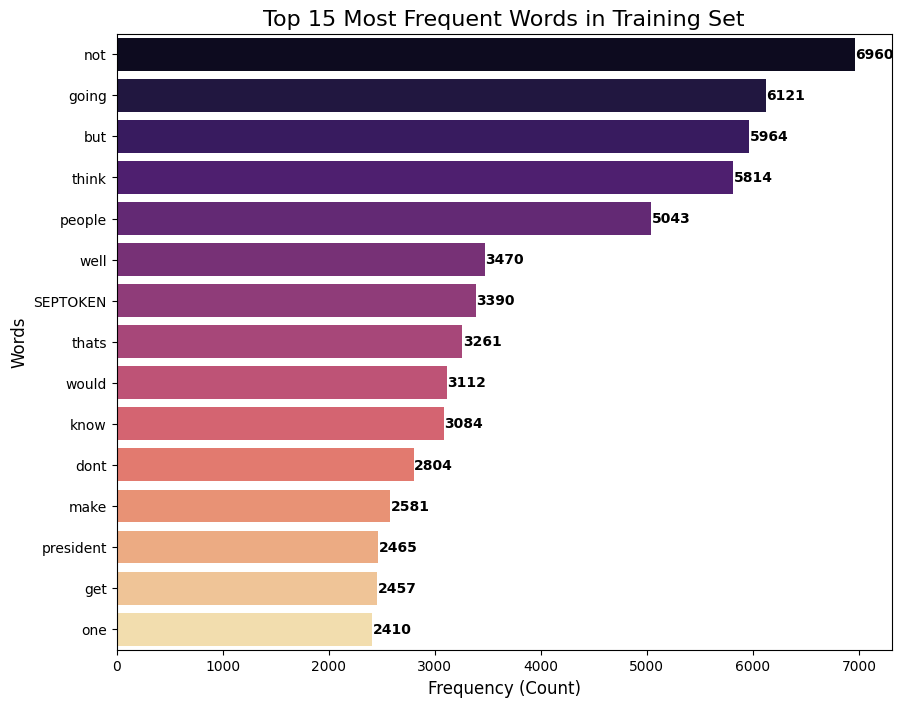

In [14]:
from collections import Counter

all_words = " ".join(df_train['clean_text']).split()
top_15_counts = Counter(all_words).most_common(15)

words = [item[0] for item in top_15_counts]
counts = [item[1] for item in top_15_counts]

plt.figure(figsize=(10, 8))
sns.barplot(x=counts, y=words, palette='magma') 

plt.title('Top 15 Most Frequent Words in Training Set', fontsize=16)
plt.xlabel('Frequency (Count)', fontsize=12)
plt.ylabel('Words', fontsize=12)

for i, v in enumerate(counts):
    plt.text(v + 3, i, str(v), color='black', va='center', fontweight='bold')
    

plt.savefig('mstfreq_words.png', bbox_inches='tight', dpi=300)
plt.show()

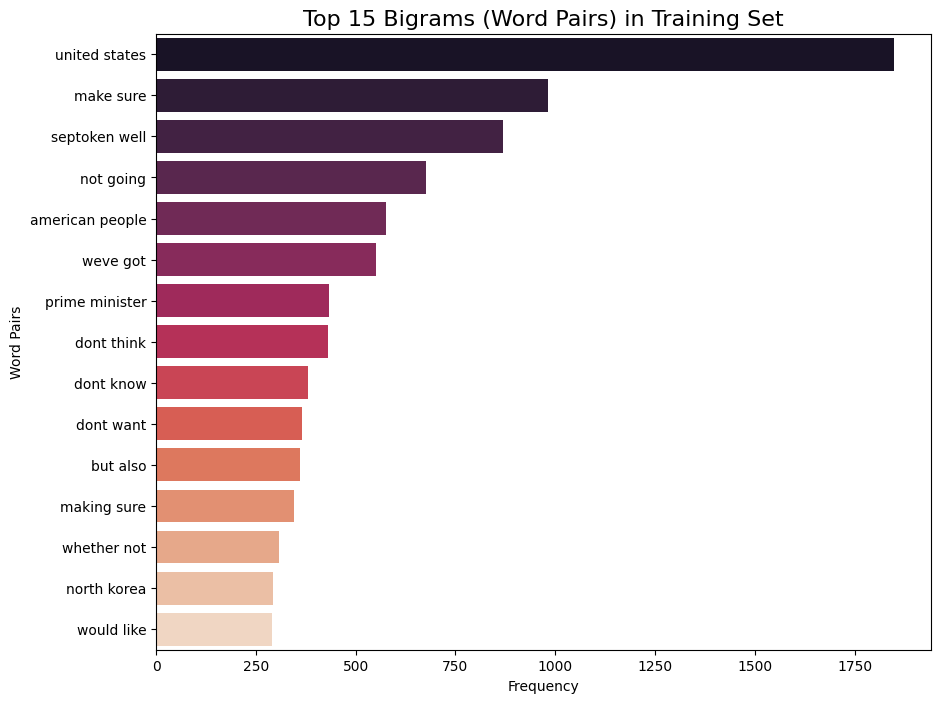

In [15]:
from sklearn.feature_extraction.text import CountVectorizer
vec = CountVectorizer(ngram_range=(2, 2)).fit(df_train['clean_text'])
bag_of_words = vec.transform(df_train['clean_text'])

sum_words = bag_of_words.sum(axis=0) 
words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]

words_freq = sorted(words_freq, key = lambda x: x[1], reverse=True)
top_15_bigrams = words_freq[:15]

df_bigrams = pd.DataFrame(top_15_bigrams, columns=['Bigram', 'Frequency'])

plt.figure(figsize=(10, 8))
sns.barplot(x='Frequency', y='Bigram', data=df_bigrams, palette='rocket', hue='Bigram', legend=False)

plt.title('Top 15 Bigrams (Word Pairs) in Training Set', fontsize=16)
plt.xlabel('Frequency')
plt.ylabel('Word Pairs')
plt.savefig('mstfreq_wordpairs.png', bbox_inches='tight', dpi=300)
plt.show()

Η συχνότητα της εμφάνισης του token SEPTOKEN, το οποίο αποτελεί δομικό διαχωριστικό του dataset, αναμένεται να "αγνοηθεί" από το μοντέλο κατά την εκπαίδευση.

Αντίστοιχα με πριν, η παρουσία του token SEPTOKEN αναμένεται να "αγνοηθεί" από το μοντέλο κατά την εκπαίδευση.  

Τώρα θα δούμε το πρώτο μας μοντέλο, TF-IDF Vectorizer & Logistic Regression (με 5-Fold Cross Validation).

In [16]:
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
nltk.download('punkt', quiet=True)

lemmatizer = WordNetLemmatizer()

def apply_lemmatization(text):
    text = str(text) 
    tokens = word_tokenize(text)
    lemmatized_tokens = [lemmatizer.lemmatize(word) for word in tokens]
    return " ".join(lemmatized_tokens)

df_train['lemmatized_text'] = df_train['clean_text'].apply(apply_lemmatization)
df_test['lemmatized_text'] = df_test['clean_text'].apply(apply_lemmatization)
print("Το Lemmatization ολοκληρώθηκε!\n")


X = df_train['lemmatized_text']
y = df_train['clarity_label']

pipeline_model1 = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1,2), max_df=0.90, min_df=5, sublinear_tf=True)),
    ('classifier', LogisticRegression(
        max_iter=1000, 
        random_state=2004, 
        class_weight='balanced'
    ))
])


skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=2004) #Το σπάω σε 5 κομμάτια

print("Ξεκινάει η 5-Fold Cross Validation για το Μοντέλο 1 (TF-IDF + Logistic Regression)!")

scoring_metrics = ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro']
cv_results = cross_validate(
    pipeline_model1, 
    X, 
    y, 
    cv=skf, 
    scoring=scoring_metrics, 
    n_jobs=-1 
)

print(f"\nΑποτελέσματα Μοντέλου 1 (TF-IDF + Logistic Regression)")
print(f"Mean Accuracy:        {np.mean(cv_results['test_accuracy']):.4f}")
print(f"Mean Macro Precision: {np.mean(cv_results['test_precision_macro']):.4f}")
print(f"Mean Macro Recall:    {np.mean(cv_results['test_recall_macro']):.4f}")
print(f"Mean Macro F1-Score:  {np.mean(cv_results['test_f1_macro']):.4f}")

Το Lemmatization ολοκληρώθηκε!

Ξεκινάει η 5-Fold Cross Validation για το Μοντέλο 1 (TF-IDF + Logistic Regression)!

Αποτελέσματα Μοντέλου 1 (TF-IDF + Logistic Regression)
Mean Accuracy:        0.5596
Mean Macro Precision: 0.5024
Mean Macro Recall:    0.5296
Mean Macro F1-Score:  0.5131


Αφού εγκαθιδρύσαμε το baseline μοντέλο με τις προεπιλεγμένες ρυθμίσεις της Logistic Regression, προχωράμε σε χειροκίνητα πειράματα. Σκοπός μας είναι να εξετάσουμε πώς διαφορετικοί συνδυασμοί κανονικοποίησης (L1 vs L2), αλγορίθμων επίλυσης (solvers) και υπερπαραμέτρου (C) επηρεάζουν το τελικό F1-Score.

In [17]:
experiments = [
    {'name': '1. Baseline (L2, C=1.0, lbfgs)', 'C': 1.0, 'penalty': 'l2', 'solver': 'lbfgs'},
    {'name': '2. Baseline με Αυστηρό Regularization (L2, C=0.1, lbfgs)', 'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'},
    {'name': '3. Baseline με Χαλαρό Regularization (L2, C=10.0, lbfgs)', 'C': 10.0, 'penalty': 'l2', 'solver': 'lbfgs'},
    {'name': '4. Αλλαγή του Baseline σε L1 με solver liblinear (L1, C=1.0, liblinear)', 'C': 1.0, 'penalty': 'l1', 'solver': 'liblinear'},
    {'name': '5. Αλλαγή του Baseline σε L1  με Αυστηρό Regularization και solver liblinear (L1, C=0.1, liblinear)', 'C': 0.1, 'penalty': 'l1', 'solver': 'liblinear'},
    {'name': '6. Αλλαγή του Baseline σε L1  με Χαλαρό Regularization και solver liblinear (L1, C=10.0, liblinear)', 'C': 10.0, 'penalty': 'l1', 'solver': 'liblinear'},
    {'name': '7. Αλλαγή του Baseline σε L1 με solver saga (L1, C=1.0, saga)', 'C': 1.0, 'penalty': 'l1', 'solver': 'saga'},
    {'name': '8. Αλλαγή του Baseline σε L1  με Αυστηρό Regularization και solver saga (L1, C=0.1, saga)', 'C': 0.1, 'penalty': 'l1', 'solver': 'saga'},
    {'name': '9. Αλλαγή του Baseline σε L1  με Χαλαρό Regularization και solver saga (L1, C=10.0, saga)', 'C': 10.0, 'penalty': 'l1', 'solver': 'saga'},

]

print("Ξεκινάνε τα Χειροκίνητα Πειράματα (TF-IDF + LR)\n")

for exp in experiments:
    pipeline = Pipeline([
        ('tfidf', TfidfVectorizer(ngram_range=(1,2), max_df=0.90, min_df=5, sublinear_tf=True)),
        ('classifier', LogisticRegression(
            max_iter=1000, 
            random_state=2004,  
            C=exp['C'], 
            penalty=exp['penalty'], 
            solver=exp['solver'],
            class_weight='balanced'
        ))
    ])
    
    
    cv_results = cross_validate(
        pipeline, X, y, cv=skf, scoring='f1_macro', n_jobs=-1
    )
    
    
    mean_f1 = np.mean(cv_results['test_score'])
    print(f"Πείραμα: {exp['name']:<28} -> Mean Macro F1: {mean_f1:.4f}")

print("\nΤέλος πειραμάτων!")

Ξεκινάνε τα Χειροκίνητα Πειράματα (TF-IDF + LR)

Πείραμα: 1. Baseline (L2, C=1.0, lbfgs) -> Mean Macro F1: 0.5131
Πείραμα: 2. Baseline με Αυστηρό Regularization (L2, C=0.1, lbfgs) -> Mean Macro F1: 0.4825
Πείραμα: 3. Baseline με Χαλαρό Regularization (L2, C=10.0, lbfgs) -> Mean Macro F1: 0.5140
Πείραμα: 4. Αλλαγή του Baseline σε L1 με solver liblinear (L1, C=1.0, liblinear) -> Mean Macro F1: 0.4614
Πείραμα: 5. Αλλαγή του Baseline σε L1  με Αυστηρό Regularization και solver liblinear (L1, C=0.1, liblinear) -> Mean Macro F1: 0.2496
Πείραμα: 6. Αλλαγή του Baseline σε L1  με Χαλαρό Regularization και solver liblinear (L1, C=10.0, liblinear) -> Mean Macro F1: 0.5038


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Πείραμα: 7. Αλλαγή του Baseline σε L1 με solver saga (L1, C=1.0, saga) -> Mean Macro F1: 0.4776
Πείραμα: 8. Αλλαγή του Baseline σε L1  με Αυστηρό Regularization και solver saga (L1, C=0.1, saga) -> Mean Macro F1: 0.3062


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Πείραμα: 9. Αλλαγή του Baseline σε L1  με Χαλαρό Regularization και solver saga (L1, C=10.0, saga) -> Mean Macro F1: 0.4954

Τέλος πειραμάτων!


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Τώρα, για να βρούμε την απόλυτα βέλτιστη τιμή και να μεγιστοποιήσουμε το F1-Score, θα χρησιμοποιήσουμε τη μέθοδο GridSearchCV. Αυτό θα εξετάσει αυτόματα και θα επιστρέψει τον ιδανικό συνδυασμό με τη μέθοδο Cross-Validation.

In [18]:
print("Ξεκινάει το GridSearchCV\n")

pipeline_grid = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1,2), max_df=0.90, min_df=5, sublinear_tf=True)),  
    ('classifier', LogisticRegression(
        max_iter=1000, 
        random_state=2004, 
        penalty='l2',
        solver='lbfgs',
        class_weight='balanced'
    ))
])

param_grid = {
    'classifier__C': [0.5, 0.7, 0.8, 0.9, 1.0, 1.5, 2.0, 2.5, 3.0, 4.0, 5.0, 9.0, 10.0, 11.0, 12.0,13.0,14.0,15.0,20.0]
}


grid_search = GridSearchCV(
    estimator=pipeline_grid,
    param_grid=param_grid,
    cv=skf,                
    scoring='f1_macro',    
    n_jobs=-1,             
    verbose=1              
)

 
grid_search.fit(X, y)

 
print("\nΑποτελέσματα Grid Search")
print(f"Η καλύτερη τιμή για το C είναι: {grid_search.best_params_['classifier__C']}")
print(f"Το Καλύτερο Mean Macro F1-Score είναι: {grid_search.best_score_:.4f}")


best_tfidf_model = grid_search.best_estimator_

Ξεκινάει το GridSearchCV

Fitting 5 folds for each of 19 candidates, totalling 95 fits

Αποτελέσματα Grid Search
Η καλύτερη τιμή για το C είναι: 3.0
Το Καλύτερο Mean Macro F1-Score είναι: 0.5213


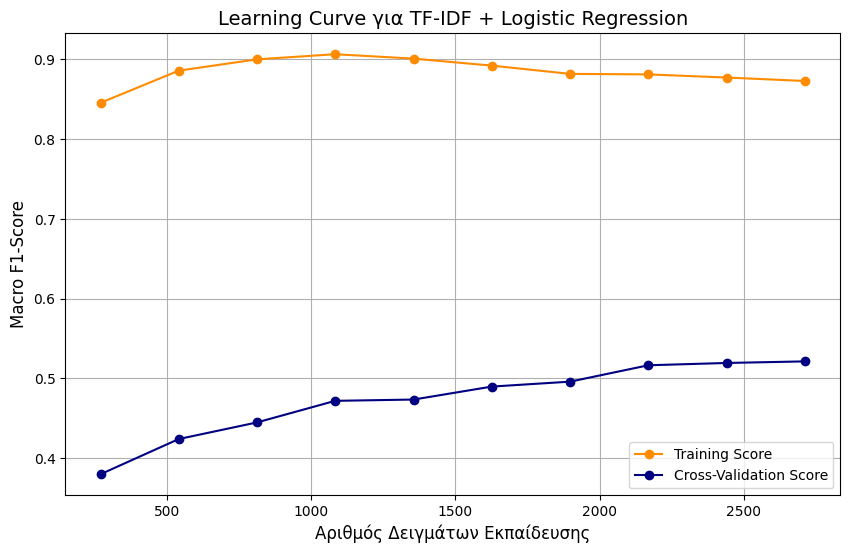

In [19]:
train_sizes, train_scores, val_scores = learning_curve(
    estimator=best_tfidf_model,
    X=X,
    y=y,
    train_sizes=np.linspace(0.1, 1.0, 10), 
    cv=skf,
    scoring='f1_macro',
    n_jobs=-1
)

train_scores_mean = np.mean(train_scores, axis=1)
val_scores_mean = np.mean(val_scores, axis=1)

plt.figure(figsize=(10, 6))
plt.title("Learning Curve για TF-IDF + Logistic Regression", fontsize=14)
plt.xlabel("Αριθμός Δειγμάτων Εκπαίδευσης", fontsize=12)
plt.ylabel("Macro F1-Score", fontsize=12)


plt.plot(train_sizes, train_scores_mean, 'o-', color="darkorange", label="Training Score")
plt.plot(train_sizes, val_scores_mean, 'o-', color="navy", label="Cross-Validation Score")

plt.legend(loc="best")
plt.grid(True)
plt.savefig('learningcurve_1_tfidf.png', bbox_inches='tight', dpi=300)
plt.show()

In [20]:
print("Αυστηρό TF-IDF - Τελική προσπάθεια\n")

pipeline_strict = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1,2), max_df=0.80, min_df=2, sublinear_tf=True)), 
                                                            
    ('classifier', LogisticRegression(
        max_iter=1000, 
        random_state=2004, 
        C=3.0,              
        penalty='l2', 
        solver='lbfgs',
        class_weight='balanced'
    ))
])


cv_results_strict = cross_validate(
    pipeline_strict, X, y, cv=skf, scoring='f1_macro', n_jobs=-1
)

mean_f1_strict = np.mean(cv_results_strict['test_score'])
print(f"Νέο Mean Macro F1-Score: {mean_f1_strict:.4f}")

Αυστηρό TF-IDF - Τελική προσπάθεια

Νέο Mean Macro F1-Score: 0.5275


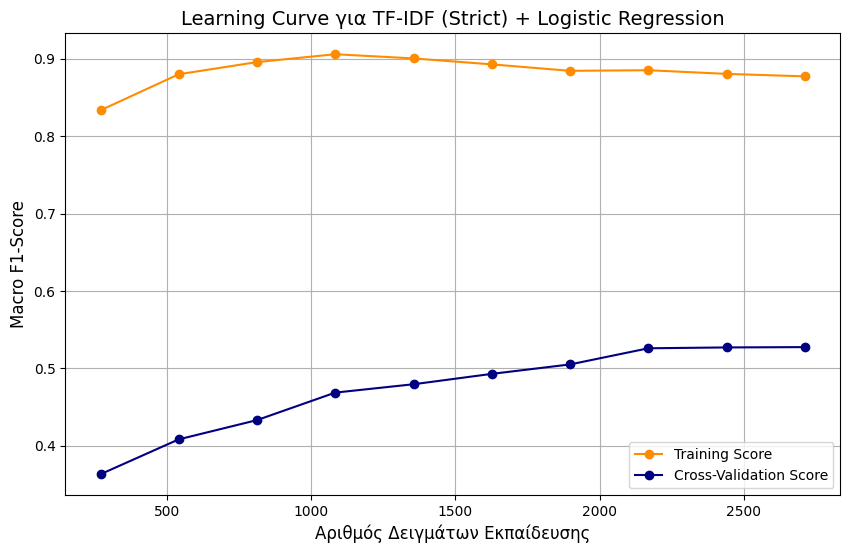

In [21]:
train_sizes, train_scores, val_scores = learning_curve(
    estimator=pipeline_strict,  
    X=X,
    y=y,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=skf,
    scoring='f1_macro',
    n_jobs=-1
)

train_scores_mean = np.mean(train_scores, axis=1)
val_scores_mean = np.mean(val_scores, axis=1)


plt.figure(figsize=(10, 6))
plt.title("Learning Curve για TF-IDF (Strict) + Logistic Regression", fontsize=14)
plt.xlabel("Αριθμός Δειγμάτων Εκπαίδευσης", fontsize=12)
plt.ylabel("Macro F1-Score", fontsize=12)

plt.plot(train_sizes, train_scores_mean, 'o-', color="darkorange", label="Training Score")
plt.plot(train_sizes, val_scores_mean, 'o-', color="navy", label="Cross-Validation Score")

plt.legend(loc="best")
plt.grid(True)
plt.savefig('learning_curve_strict_tfidf.png', bbox_inches='tight', dpi=300)
plt.show()

In [22]:
print("Ξεκινάει το GridSearchCV\n")

pipeline_grid = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1,2), max_df=0.80, min_df=2, sublinear_tf=True)),
    ('classifier', LogisticRegression(
        max_iter=1000,
        random_state=2004,
        penalty='l2',
        solver='lbfgs',
        class_weight='balanced'
    ))
])

param_grid = {
    'classifier__C': [0.5, 0.7, 0.8, 0.9, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 9.0, 10.0]
}

grid_search = GridSearchCV(
    estimator=pipeline_grid,
    param_grid=param_grid,
    cv=skf,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X, y)

print("\nΑποτελέσματα Grid Search")
print(f"Η καλύτερη τιμή για το C είναι: {grid_search.best_params_['classifier__C']}")
print(f"Το Καλύτερο Mean Macro F1-Score είναι: {grid_search.best_score_:.4f}")

best_tfidf_model = grid_search.best_estimator_
print("Υπολογισμός όλων των μετρικών για το καλύτερο μοντέλο.\n")
scoring_list = ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro']
cv_results_final = cross_validate(
    best_tfidf_model, X, y, 
    cv=skf, 
    scoring=scoring_list, 
    n_jobs=-1
)
print("Τελικές Μετρικές:")
print(f"Accuracy:  {cv_results_final['test_accuracy'].mean():.4f}")
print(f"Precision: {cv_results_final['test_precision_macro'].mean():.4f}")
print(f"Recall:    {cv_results_final['test_recall_macro'].mean():.4f}")
print(f"F1-Score:  {cv_results_final['test_f1_macro'].mean():.4f}")

Ξεκινάει το GridSearchCV

Fitting 5 folds for each of 15 candidates, totalling 75 fits

Αποτελέσματα Grid Search
Η καλύτερη τιμή για το C είναι: 2.0
Το Καλύτερο Mean Macro F1-Score είναι: 0.5309
Υπολογισμός όλων των μετρικών για το καλύτερο μοντέλο.

Τελικές Μετρικές:
Accuracy:  0.5850
Precision: 0.5346
Recall:    0.5277
F1-Score:  0.5309


Επειδή το TF-IDF υποφέρει από την αραιότητα (sparsity) και οδηγεί σε overfitting, στο επόμενο βήμα θα δοκιμάσουμε Word Embeddings (GloVe). Πρώτα όμως, θα ερευνήσουμε το ζήτημα με τα εξής διαγράμματα:

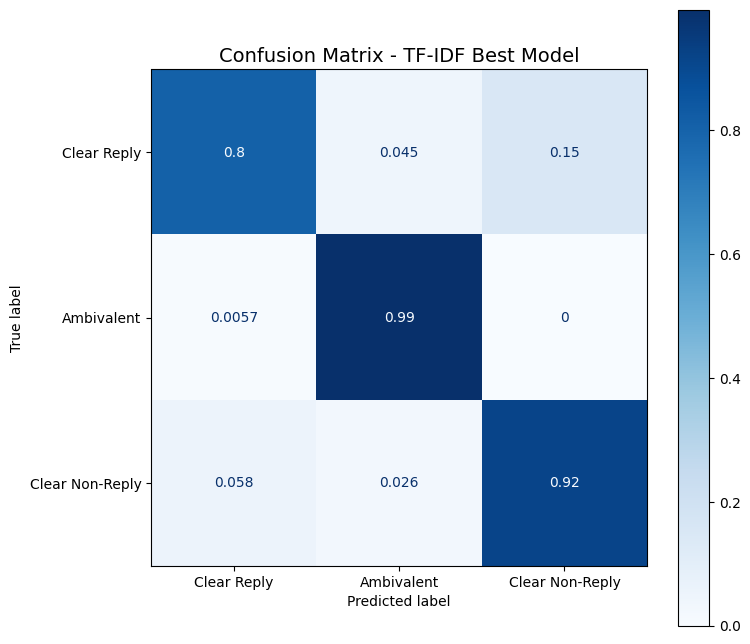

In [23]:
fig, ax = plt.subplots(figsize=(8, 8))
ConfusionMatrixDisplay.from_estimator(
    best_tfidf_model, X, y, 
    display_labels=['Clear Reply', 'Ambivalent', 'Clear Non-Reply'],  
    cmap='Blues', 
    normalize='true',
    ax=ax
)

plt.title("Confusion Matrix - TF-IDF Best Model", fontsize=14)
plt.savefig('confmatrix_tfidf_bestmod.png', bbox_inches='tight', dpi=300)
plt.show()

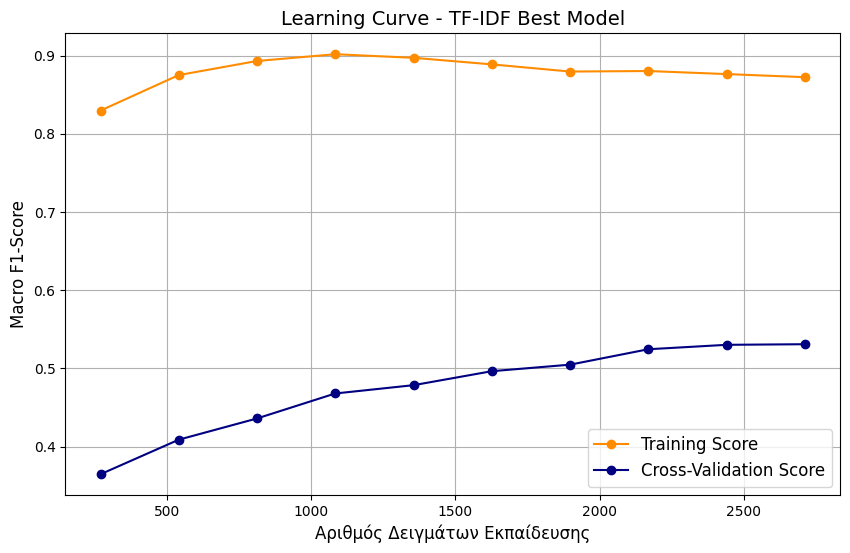

In [24]:
train_sizes, train_scores, test_scores = learning_curve(
    estimator=best_tfidf_model,
    X=X,
    y=y,
    cv=skf,                  
    scoring='f1_macro',      
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10)  
)

 
train_scores_mean = np.mean(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)

 
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_scores_mean, 'o-', color="darkorange", label="Training Score")
plt.plot(train_sizes, test_scores_mean, 'o-', color="navy", label="Cross-Validation Score")

plt.title("Learning Curve - TF-IDF Best Model", fontsize=14)
plt.xlabel("Αριθμός Δειγμάτων Εκπαίδευσης", fontsize=12)
plt.ylabel("Macro F1-Score", fontsize=12)
plt.grid(True)
plt.legend(loc="lower right", fontsize=12)

plt.savefig('learning_curve_tfidf_bestmod.png', bbox_inches='tight', dpi=300)
plt.show()

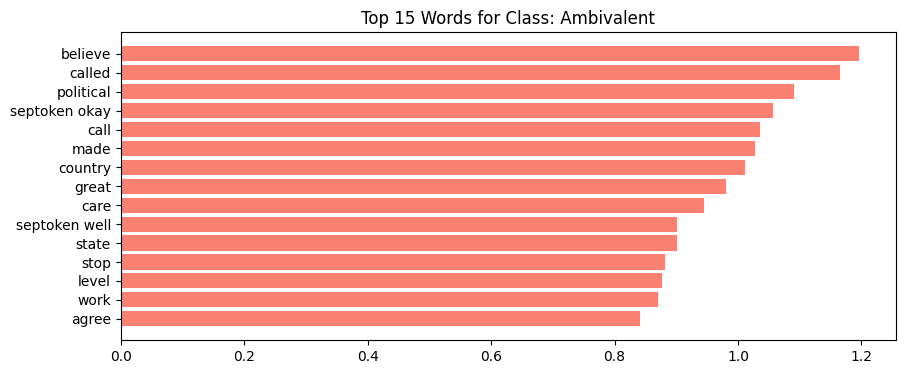

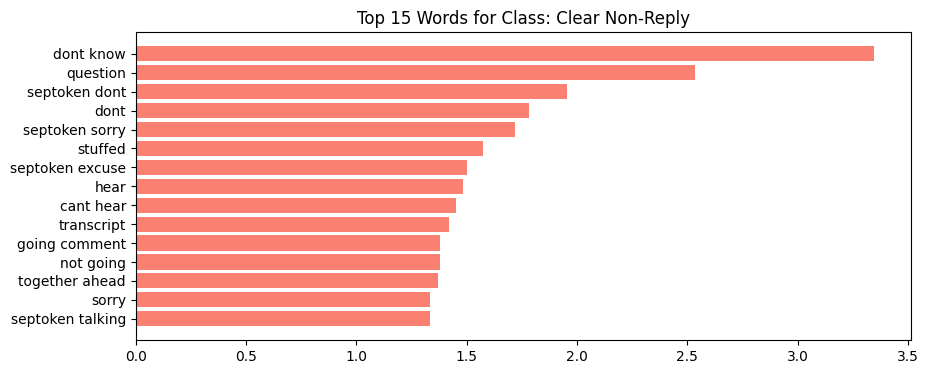

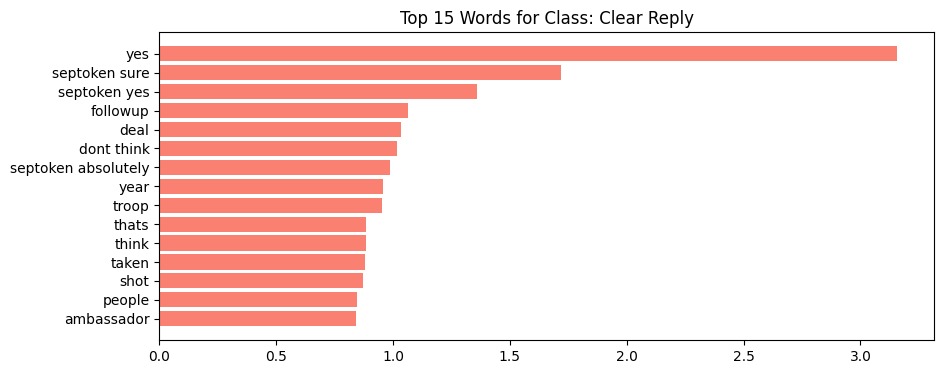

In [25]:
class_names = best_tfidf_model.named_steps['classifier'].classes_
feature_names = best_tfidf_model.named_steps['tfidf'].get_feature_names_out()
coefficients = best_tfidf_model.named_steps['classifier'].coef_

for i, class_name in enumerate(class_names):
    top_words = sorted(zip(coefficients[i], feature_names), reverse=True)[:15]
    
    plt.figure(figsize=(10, 4))
    plt.barh([w[1] for w in top_words], [w[0] for w in top_words], color='salmon')
    plt.title(f'Top 15 Words for Class: {class_name}')
    plt.gca().invert_yaxis()
    filename = f"top_words_{class_name.replace(' ', '_')}.png"
    plt.savefig(filename, bbox_inches='tight', dpi=300)
    plt.show()

Τώρα θα εξετάσουμε τη χρήση των Word Embeddings (GloVe), τα οποία αναπαριστούν τις λέξεις σε έναν συνεχή διανυσματικό χώρο, επιτρέποντας έτσι στο μοντέλο να εκμεταλλευτεί νοηματικές συσχετίσεις μεταξύ των λέξεων.

In [26]:
try:
    _create_unverified_https_context = ssl._create_unverified_context
except AttributeError:
    pass
else:
    ssl._create_default_https_context = _create_unverified_https_context

nltk.download('punkt')
nltk.download('punkt_tab')


GloVe_model = api.load('glove-wiki-gigaword-100')
print("Το μοντέλο φορτώθηκε επιτυχώς!")



def get_sentence_embedding(text, model):
    text = str(text) 
    tokens = word_tokenize(text.lower())
    valid_tokens = [word for word in tokens if word in model] #Φιλτράρισμα OOV (Out-Of-Vocabulary)
    
    if not valid_tokens:
        return np.zeros(model.vector_size)
    
    word_vectors = [model[word] for word in valid_tokens]
    return np.mean(word_vectors, axis=0)

[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /usr/share/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


[==================================================] 100.0% 128.1/128.1MB downloaded
Το μοντέλο φορτώθηκε επιτυχώς!


In [27]:
print("Μετατροπή των Training κειμένων σε GloVe Embeddings.")
X_train_GloVe = np.array([get_sentence_embedding(text, GloVe_model) for text in df_train['clean_text']])
y_train = df_train['clarity_label']

print("Μετατροπή των Test κειμένων σε GloVe Embeddings.")
X_test_GloVe = np.array([get_sentence_embedding(text, GloVe_model) for text in df_test['clean_text']])

print(f"Το σχήμα των νέων δεδομένων X_train είναι: {X_train_GloVe.shape}")

Μετατροπή των Training κειμένων σε GloVe Embeddings.
Μετατροπή των Test κειμένων σε GloVe Embeddings.
Το σχήμα των νέων δεδομένων X_train είναι: (3390, 100)


In [28]:
pipeline_GloVe_baseline = Pipeline([
    ('scaler', MinMaxScaler()), 
    ('classifier', LogisticRegression(
        max_iter=1000, 
        random_state=2004,
        class_weight='balanced'
    ))
])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=2004)

print("Ξεκινάει η 5-Fold Cross Validation για το Μοντέλο 2 (GloVe + Logistic Regression)!")

scoring_metrics = ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro']
cv_results_GloVe = cross_validate(
    pipeline_GloVe_baseline, 
    X_train_GloVe, 
    y_train, 
    cv=skf, 
    scoring=scoring_metrics, 
    n_jobs=-1 
)

 
print(f"\nΑποτελέσματα Μοντέλου 2 (GloVe + Logistic Regression)")
print(f"Mean Accuracy:        {np.mean(cv_results_GloVe['test_accuracy']):.4f}")
print(f"Mean Macro Precision: {np.mean(cv_results_GloVe['test_precision_macro']):.4f}")
print(f"Mean Macro Recall:    {np.mean(cv_results_GloVe['test_recall_macro']):.4f}")
print(f"Mean Macro F1-Score:  {np.mean(cv_results_GloVe['test_f1_macro']):.4f}")

Ξεκινάει η 5-Fold Cross Validation για το Μοντέλο 2 (GloVe + Logistic Regression)!

Αποτελέσματα Μοντέλου 2 (GloVe + Logistic Regression)
Mean Accuracy:        0.4696
Mean Macro Precision: 0.4073
Mean Macro Recall:    0.4538
Mean Macro F1-Score:  0.4112


In [29]:
experiments = [
    {'name': '1. Baseline (L2, C=1.0, lbfgs)', 'C': 1.0, 'penalty': 'l2', 'solver': 'lbfgs'},
    {'name': '2. Baseline με Αυστηρό Regularization (L2, C=0.1, lbfgs)', 'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'},
    {'name': '3. Baseline με Χαλαρό Regularization (L2, C=10.0, lbfgs)', 'C': 10.0, 'penalty': 'l2', 'solver': 'lbfgs'},
    {'name': '4. Αλλαγή του Baseline σε L1 με solver liblinear (L1, C=1.0, liblinear)', 'C': 1.0, 'penalty': 'l1', 'solver': 'liblinear'},
    {'name': '5. Αλλαγή του Baseline σε L1 με Αυστηρό Regularization (L1, C=0.1, liblinear)', 'C': 0.1, 'penalty': 'l1', 'solver': 'liblinear'},
    {'name': '6. Αλλαγή του Baseline σε L1 με Χαλαρό Regularization (L1, C=10.0, liblinear)', 'C': 10.0, 'penalty': 'l1', 'solver': 'liblinear'},
    {'name': '7. Αλλαγή του Baseline σε L1 με solver saga (L1, C=1.0, saga)', 'C': 1.0, 'penalty': 'l1', 'solver': 'saga'},
    {'name': '8. Αλλαγή του Baseline σε L1 με Αυστηρό Regularization (L1, C=0.1, saga)', 'C': 0.1, 'penalty': 'l1', 'solver': 'saga'},
    {'name': '9. Αλλαγή του Baseline σε L1 με Χαλαρό Regularization (L1, C=10.0, saga)', 'C': 10.0, 'penalty': 'l1', 'solver': 'saga'},
]

print("Ξεκινάνε τα Χειροκίνητα Πειράματα (GloVe + LR)\n") 

for exp in experiments:
    pipeline = Pipeline([
        ('scaler', MinMaxScaler()), 
        ('classifier', LogisticRegression(
            max_iter=1000, 
            random_state=2004, 
            C=exp['C'], 
            penalty=exp['penalty'], 
            solver=exp['solver'],
            class_weight='balanced'
        ))
    ]) 
    
    cv_results = cross_validate(
        pipeline, X_train_GloVe, y_train, cv=skf, scoring='f1_macro', n_jobs=-1
    )
    
    mean_f1 = np.mean(cv_results['test_score'])
    print(f"Πείραμα: {exp['name']:<75} -> Mean Macro F1: {mean_f1:.4f}")

print("\nΤέλος πειραμάτων!")

Ξεκινάνε τα Χειροκίνητα Πειράματα (GloVe + LR)

Πείραμα: 1. Baseline (L2, C=1.0, lbfgs)                                              -> Mean Macro F1: 0.4112
Πείραμα: 2. Baseline με Αυστηρό Regularization (L2, C=0.1, lbfgs)                    -> Mean Macro F1: 0.3986
Πείραμα: 3. Baseline με Χαλαρό Regularization (L2, C=10.0, lbfgs)                    -> Mean Macro F1: 0.4113
Πείραμα: 4. Αλλαγή του Baseline σε L1 με solver liblinear (L1, C=1.0, liblinear)     -> Mean Macro F1: 0.4054
Πείραμα: 5. Αλλαγή του Baseline σε L1 με Αυστηρό Regularization (L1, C=0.1, liblinear) -> Mean Macro F1: 0.3014
Πείραμα: 6. Αλλαγή του Baseline σε L1 με Χαλαρό Regularization (L1, C=10.0, liblinear) -> Mean Macro F1: 0.4235
Πείραμα: 7. Αλλαγή του Baseline σε L1 με solver saga (L1, C=1.0, saga)               -> Mean Macro F1: 0.4066
Πείραμα: 8. Αλλαγή του Baseline σε L1 με Αυστηρό Regularization (L1, C=0.1, saga)    -> Mean Macro F1: 0.3523


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Πείραμα: 9. Αλλαγή του Baseline σε L1 με Χαλαρό Regularization (L1, C=10.0, saga)    -> Mean Macro F1: 0.4064

Τέλος πειραμάτων!


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [30]:
param_grid_fine = {
    'classifier__C': [5.0, 7.5, 8.0, 9.0, 10.0, 11.0, 12.0, 13.5, 15.0],
    'classifier__penalty': ['l1'],
    'classifier__solver': ['liblinear']
}


final_pipeline = Pipeline([
    ('scaler', MinMaxScaler()), 
    ('classifier', LogisticRegression(
        max_iter=1000, 
        random_state=2004,
        class_weight='balanced'
    ))
])


grid_search_fine = GridSearchCV(
    estimator=final_pipeline,
    param_grid=param_grid_fine,
    cv=skf,            
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

grid_search_fine.fit(X_train_GloVe, y_train)

print(f"\nΚαλύτερο C βρέθηκε: {grid_search_fine.best_params_['classifier__C']}")
print(f"Καλύτερο F1-Score: {grid_search_fine.best_score_:.4f}")

Fitting 5 folds for each of 9 candidates, totalling 45 fits

Καλύτερο C βρέθηκε: 5.0
Καλύτερο F1-Score: 0.4279


In [31]:
param_grid_extra_fine = {
    'classifier__C': [2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0, 6.5, 7.0, 7.5], 
    'classifier__penalty': ['l1'],
    'classifier__solver': ['liblinear']
}

grid_search_extra = GridSearchCV(
    estimator=final_pipeline,
    param_grid=param_grid_extra_fine,
    cv=skf,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

grid_search_extra.fit(X_train_GloVe, y_train)


print(f"\nΟριστικός Νικητής (C): {grid_search_extra.best_params_['classifier__C']}")
print(f"Οριστικό καλύτερο F1-Score: {grid_search_extra.best_score_:.4f}")


best_GloVe_model = grid_search_extra.best_estimator_
print("\nΥπολογισμός όλων των μετρικών για το καλύτερο GloVe μοντέλο.\n")
cv_results_GloVe = cross_validate(
    best_GloVe_model, 
    X_train_GloVe,    # Τα δεδομένα GloVe
    y_train,        # Οι ετικέτες σου
    cv=skf, 
    scoring=scoring_list, 
    n_jobs=-1
)
print("Τελικές Μετρικές GloVe:")
print(f"Accuracy:  {cv_results_GloVe['test_accuracy'].mean():.4f}")
print(f"Precision: {cv_results_GloVe['test_precision_macro'].mean():.4f}")
print(f"Recall:    {cv_results_GloVe['test_recall_macro'].mean():.4f}")
print(f"F1-Score:  {cv_results_GloVe['test_f1_macro'].mean():.4f}")

Fitting 5 folds for each of 11 candidates, totalling 55 fits

Οριστικός Νικητής (C): 4.5
Οριστικό καλύτερο F1-Score: 0.4281

Υπολογισμός όλων των μετρικών για το καλύτερο GloVe μοντέλο.

Τελικές Μετρικές GloVe:
Accuracy:  0.5625
Precision: 0.4462
Recall:    0.4476
F1-Score:  0.4281


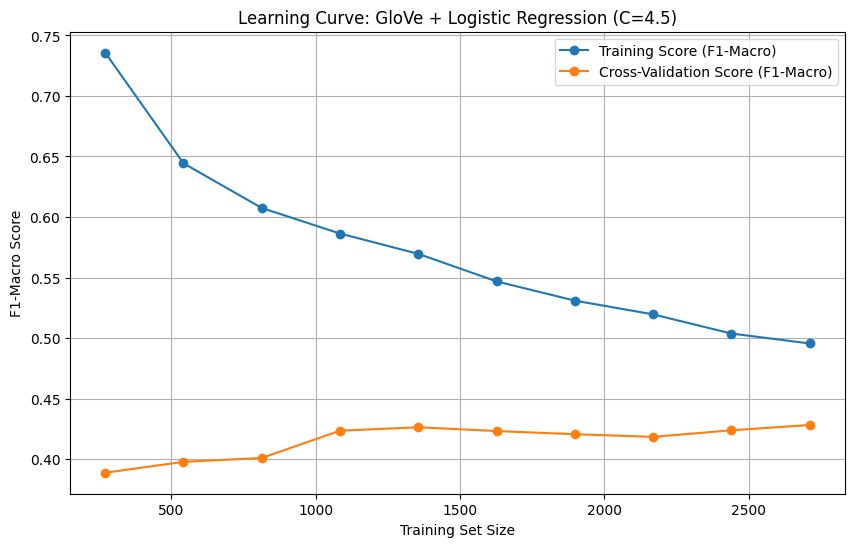

In [32]:
final_GloVe_model = Pipeline([
    ('scaler', MinMaxScaler()), 
    ('classifier', LogisticRegression(
        C=4.5, 
        penalty='l1', 
        solver='liblinear', 
        max_iter=1000, 
        random_state=2004,
        class_weight='balanced'
    ))
])


train_sizes, train_scores, val_scores = learning_curve(
    final_GloVe_model, 
    X_train_GloVe, 
    y_train, 
    cv=skf, 
    scoring='f1_macro', 
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10)  
)

train_mean = np.mean(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, label='Training Score (F1-Macro)', marker='o')
plt.plot(train_sizes, val_mean, label='Cross-Validation Score (F1-Macro)', marker='o')
plt.title('Learning Curve: GloVe + Logistic Regression (C=4.5)')
plt.xlabel('Training Set Size')
plt.ylabel('F1-Macro Score')
plt.legend(loc='best')
plt.grid(True)
plt.savefig('learning_curve_GloVe_bestmod.png', bbox_inches='tight', dpi=300)
plt.show()

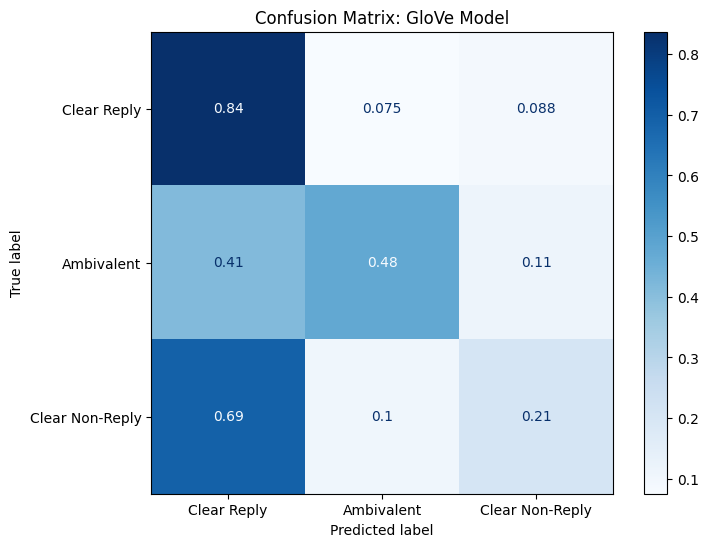

In [33]:
final_GloVe_model.fit(X_train_GloVe, y_train)
y_pred = final_GloVe_model.predict(X_train_GloVe)
cm = confusion_matrix(y_train, y_pred, normalize='true')

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Clear Reply', 'Ambivalent', 'Clear Non-Reply'])
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.title('Confusion Matrix: GloVe Model')
plt.savefig('confmatrix_GloVe_bestmod.png', bbox_inches='tight', dpi=300)
plt.show()

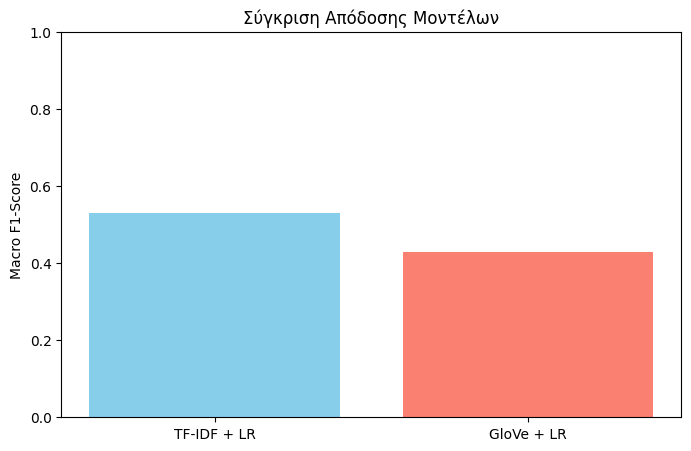

In [34]:
models = ['TF-IDF + LR', 'GloVe + LR']
f1_scores = [0.5309, 0.4281]  

plt.figure(figsize=(8, 5))
plt.bar(models, f1_scores, color=['skyblue', 'salmon'])
plt.ylabel('Macro F1-Score')
plt.title('Σύγκριση Απόδοσης Μοντέλων')
plt.ylim(0, 1) 
plt.savefig('comparison_bestmods.png', bbox_inches='tight', dpi=300)
plt.show()

In [35]:
final_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1,2), max_df=0.90, min_df=5, sublinear_tf=True)),
    ('classifier', LogisticRegression(C=3.0, class_weight='balanced', solver='lbfgs', max_iter=1000, penalty = 'l2', random_state=2004))
])


cv_predictions = cross_val_predict(final_pipeline, df_train['lemmatized_text'], df_train['clarity_label'], cv=5)
error_analysis_df = pd.DataFrame({
    'Text': df_train['lemmatized_text'], 
    'Actual': df_train['clarity_label'],
    'Predicted': cv_predictions
})
severe_errors = error_analysis_df[
    (error_analysis_df['Actual'] == 'Clear Non-Reply') & 
    (error_analysis_df['Predicted'] == 'Clear Reply')

    ]

print(f"Βρέθηκαν {len(severe_errors)} σοβαρά λάθη. Εδώ είναι 5 από αυτά:\n")
for index, row in severe_errors.head(5).iterrows():
    print("-" * 70)
    print(f"ΚΕΙΜΕΝΟ: {row['Text']}")
    print(f">> ΠΡΑΓΜΑΤΙΚΟΤΗΤΑ: {row['Actual']} | ΠΡΟΒΛΕΨΗ: {row['Predicted']}\n")

Βρέθηκαν 71 σοβαρά λάθη. Εδώ είναι 5 από αυτά:

----------------------------------------------------------------------
ΚΕΙΜΕΝΟ: confident oil price cap russian export would bring price american driver SEPTOKEN let hear thethe second part question would bring price
>> ΠΡΑΓΜΑΤΙΚΟΤΗΤΑ: Clear Non-Reply | ΠΡΟΒΛΕΨΗ: Clear Reply

----------------------------------------------------------------------
ΚΕΙΜΕΝΟ: couldif chemical weapon used ukraine would trigger military response nato SEPTOKEN would trigger response kind whether notyoure asking whether nato would cross wed make decision timeus humanitarian assistance
>> ΠΡΑΓΜΑΤΙΚΟΤΗΤΑ: Clear Non-Reply | ΠΡΟΒΛΕΨΗ: Clear Reply

----------------------------------------------------------------------
ΚΕΙΜΕΝΟ: putin invade ukraine revert containment policy SEPTOKEN answer think still not want fullblown war number onenumber two think hell test west test united state nato significantly yes think but think hell pay serious dear price doesnt think cost goi

In [36]:
GloVe_cv_predictions = cross_val_predict(
    final_GloVe_model, 
    X_train_GloVe, 
    y_train, 
    cv=skf,
    n_jobs=-1
)

comparison_df = pd.DataFrame({
    'Text': df_train['lemmatized_text'],  
    'Actual': y_train,                    
    'TFIDF_Pred': cv_predictions,         
    'GloVe_Pred': GloVe_cv_predictions        
})

 
GloVe_wins = comparison_df[
    (comparison_df['Actual'] == comparison_df['GloVe_Pred']) & 
    (comparison_df['Actual'] != comparison_df['TFIDF_Pred'])
]

print(f"\n Βρέθηκαν {len(GloVe_wins)} παραδείγματα όπου το GloVe ήταν σωστό και το TF-IDF έκανε λάθος")
for index, row in GloVe_wins.head(3).iterrows():
    print("-" * 80)
    print(f"ΚΕΙΜΕΝΟ: {row['Text']}")
    print(f"ΠΡΑΓΜΑΤΙΚΟΤΗΤΑ: {row['Actual']} | ΛΑΘΟΣ ΠΡΟΒΛΕΨΗ TF-IDF: {row['TFIDF_Pred']}\n")

tfidf_wins = comparison_df[
    (comparison_df['Actual'] == comparison_df['TFIDF_Pred']) & 
    (comparison_df['Actual'] != comparison_df['GloVe_Pred'])
]

print(f"\n Βρέθηκαν {len(tfidf_wins)} παραδείγματα όπου το TF-IDF ήταν σωστό και το GloVe έκανε λάθος")
for index, row in tfidf_wins.head(3).iterrows():
    print("-" * 80)
    print(f"ΚΕΙΜΕΝΟ: {row['Text']}")
    print(f"ΠΡΑΓΜΑΤΙΚΟΤΗΤΑ: {row['Actual']} | ΛΑΘΟΣ ΠΡΟΒΛΕΨΗ GloVe: {row['GloVe_Pred']}\n")


 Βρέθηκαν 657 παραδείγματα όπου το GloVe ήταν σωστό και το TF-IDF έκανε λάθος
--------------------------------------------------------------------------------
ΚΕΙΜΕΝΟ: believe country slowdown growth could risk destabilizing global economy cause china aggressive defensively including taiwan SEPTOKEN look think china difficult economic problem right whole range reason relate international growth lack thereof policy china followedand dont think going cause china invade taiwan matter fact opposite probably doesnt capacity beforebut said notwere not looking hurt china sincerely better china well china well international rule grows economybut real difficulty term economy late particularly real estate asidethat end bargain think action theyre going take one aretheyre process deciding right not going predict way come but not looking decouple chinawhat not going not going sell china material would enhance capacity make nuclear weapon engage defense activity contrary viewed people would think 

In [37]:
final_pipeline.fit(df_train['lemmatized_text'], df_train['clarity_label'])

test_predictions = final_pipeline.predict(df_test['lemmatized_text'])

submission = pd.DataFrame({
    'Id': range(len(df_test)), 
    'Predicted': test_predictions 
})
submission.to_csv('submission.csv', index=False)
print("Το αρχείο submission.csv είναι έτοιμο!")

Το αρχείο submission.csv είναι έτοιμο!
